# Retail Demand Forecasting and Dynamic Pricing Optimization

**Dataset:** Food Demand Forecasting (Kaggle) — `train.csv`, `meal_info.csv`, `fulfilment_center_info.csv`

**Project goal:** Build an end-to-end pipeline that (1) forecasts demand and (2) recommends optimized pricing to maximize revenue.

**Pipeline stages:**
1. Data loading and merging
2. Data quality checks
3. Exploratory data analysis (EDA)
4. Feature engineering
5. Demand forecasting model
6. Price elasticity estimation
7. Price optimization
8. Evaluation


## 0. A note on dataset selection

We initially explored a different Kaggle dataset (`Retail Store Inventory Forecasting Dataset`). Before building any models on it, we ran a signal-verification check: regressing `Units Sold` on every available feature (store, product, category, region, day of week, month) combined.

**Result: R² = 0.0007** — essentially zero. The target had no learnable relationship with any feature in that dataset (most likely generated as random noise). Building forecasting or pricing models on it would have produced numbers that looked legitimate but were statistically meaningless.

We switched to the **Food Demand Forecasting** dataset instead, which we verify below has genuine, learnable signal.

**Lesson:** always verify a dataset has real signal before investing time in modeling it. A model that fits noise will still produce plots and metrics — it just won't mean anything.


## 1. Imports and data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')


In [ ]:
train = pd.read_csv('train.csv')
meal_info = pd.read_csv('meal_info.csv')
center_info = pd.read_csv('fulfilment_center_info.csv')

print('train shape:', train.shape)
print('meal_info shape:', meal_info.shape)
print('center_info shape:', center_info.shape)


train shape: (456548, 9)
meal_info shape: (51, 3)
center_info shape: (77, 5)


In [ ]:
train.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [ ]:
meal_info.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [ ]:
center_info.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


### Merge into a single working table

`train.csv` is the transactional backbone (one row per week/center/meal). We join the two lookup tables onto it using `meal_id` and `center_id`.


In [ ]:
df = train.merge(meal_info, on='meal_id', how='left').merge(center_info, on='center_id', how='left')
print('Merged shape:', df.shape)
df.head()


Merged shape: (456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


## 2. Data quality checks

Before any analysis, we check for the usual suspects: missing values, duplicates, and suspicious/impossible values.


In [ ]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Fully duplicate rows:', df.duplicated().sum())
print('Duplicate (week, center_id, meal_id) combos:', df.duplicated(subset=['week','center_id','meal_id']).sum())


Missing values per column:


id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64



Fully duplicate rows: 0
Duplicate (week, center_id, meal_id) combos: 0


In [ ]:
print('Any non-positive prices?')
print('checkout_price <= 0:', (df['checkout_price'] <= 0).sum())
print('base_price <= 0:', (df['base_price'] <= 0).sum())


Any non-positive prices?
checkout_price <= 0: 0
base_price <= 0: 0


### Investigating: checkout_price > base_price

`checkout_price` is documented as the final price including discount, taxes, and delivery charges — so in principle it could land above `base_price` even without a "markup." Worth checking directly rather than assuming.


In [ ]:
markup_rows = df[df['checkout_price'] > df['base_price']].copy()
markup_rows['markup_pct'] = (markup_rows['checkout_price'] - markup_rows['base_price']) / markup_rows['base_price'] * 100

print(f"Rows where checkout_price > base_price: {len(markup_rows):,} out of {len(df):,} ({len(markup_rows)/len(df)*100:.1f}%)")
print()
print('Markup size distribution (in currency units):')
print((markup_rows['checkout_price'] - markup_rows['base_price']).describe())


Rows where checkout_price > base_price: 116,101 out of 456,548 (25.4%)

Markup size distribution (in currency units):
count    116101.000000
mean          1.854677
std           4.565274
min           0.030000
25%           1.000000
50%           1.000000
75%           2.000000
max         185.300000
dtype: float64


In [ ]:
print('Rows with markup > 10% of base price:', (markup_rows['markup_pct'] > 10).sum())
print('Rows with markup > 50% of base price:', (markup_rows['markup_pct'] > 50).sum())
print()
print('Top 5 largest markups:')
markup_rows.nlargest(5, 'markup_pct')[['week','center_id','meal_id','base_price','checkout_price','markup_pct','num_orders']]


Rows with markup > 10% of base price: 814
Rows with markup > 50% of base price: 15

Top 5 largest markups:


,week,center_id,meal_id,base_price,checkout_price,markup_pct,num_orders
445563,142,72,2631,96.03,165.93,72.789753,81
445564,142,72,1248,97.03,163.02,68.009894,80
442313,141,72,2631,98.03,163.93,67.224319,69
442314,141,72,1248,98.03,163.93,67.224319,27
328497,106,23,1230,324.01,509.31,57.189593,107


**Conclusion:** the median markup is about \$1 (well under 1% of base price) — consistent with small delivery/tax fees rather than a data error. A small tail (814 rows, 0.18%) show larger markups, and 15 rows exceed 50% — rare enough not to distort modeling, but worth knowing about. We leave these rows in as-is; they are not errors.


## 3. Signal verification

The most important check in this whole notebook. Before trusting this dataset with real modeling effort, we confirm that price and promotions actually relate to demand — learning this lesson the hard way from the previous dataset.


In [ ]:
print('Correlation: checkout_price vs num_orders:', df['checkout_price'].corr(df['num_orders']).round(4))
print('Correlation: base_price vs num_orders:', df['base_price'].corr(df['num_orders']).round(4))

df['discount'] = df['base_price'] - df['checkout_price']
print('Correlation: discount vs num_orders:', df['discount'].corr(df['num_orders']).round(4))


Correlation: checkout_price vs num_orders: -0.2821
Correlation: base_price vs num_orders: -0.2223
Correlation: discount vs num_orders: 0.1529


In [ ]:
print('Avg orders WITH homepage feature:   ', df[df['homepage_featured']==1]['num_orders'].mean().round(1))
print('Avg orders WITHOUT homepage feature:', df[df['homepage_featured']==0]['num_orders'].mean().round(1))
print()
print('Avg orders WITH emailer promo:   ', df[df['emailer_for_promotion']==1]['num_orders'].mean().round(1))
print('Avg orders WITHOUT emailer promo:', df[df['emailer_for_promotion']==0]['num_orders'].mean().round(1))


Avg orders WITH homepage feature:    594.9
Avg orders WITHOUT homepage feature: 221.1

Avg orders WITH emailer promo:    631.1


Avg orders WITHOUT emailer promo: 229.3


**Conclusion:** unlike the previous dataset, this one has real, business-sensible relationships:
- Higher price → meaningfully fewer orders (correlation -0.28)
- Bigger discount → more orders (+0.15)
- Homepage feature and email promotion each roughly **2.7x** average demand

This dataset is safe to build on.


## 4. Exploratory data analysis

### 4.1 Target variable: `num_orders`


In [ ]:
print(df['num_orders'].describe())
print()
print('Skewness:', df['num_orders'].skew().round(3))


count    456548.000000
mean        261.872760
std         395.922798
min          13.000000
25%          54.000000
50%         136.000000
75%         324.000000
max       24299.000000
Name: num_orders, dtype: float64

Skewness: 6.93


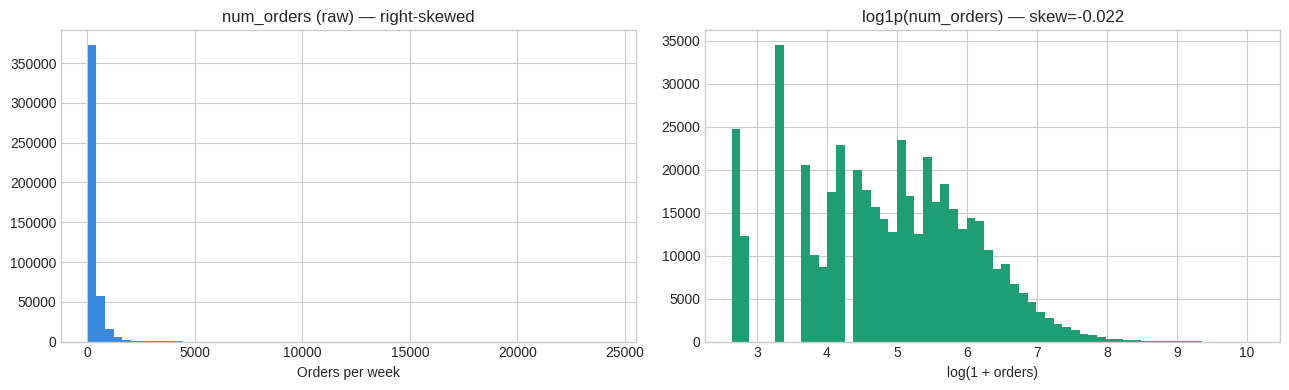

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['num_orders'], bins=60, color='#378ADD')
axes[0].set_title('num_orders (raw) — right-skewed')
axes[0].set_xlabel('Orders per week')

log_orders = np.log1p(df['num_orders'])
axes[1].hist(log_orders, bins=60, color='#1D9E75')
axes[1].set_title(f'log1p(num_orders) — skew={log_orders.skew():.3f}')
axes[1].set_xlabel('log(1 + orders)')

plt.tight_layout()
plt.show()


The raw target is heavily right-skewed (skew ≈ 6.9): most rows have modest order counts, but a long tail of large-demand weeks pulls the distribution out. Training directly on this would let rare large values dominate the loss function.

**Decision:** we model `log1p(num_orders)` as the target. After the log transform, skewness drops to roughly 0, which is far more suitable for regression models. We reverse the transform (`expm1`) to get real order-count predictions back out.


### 4.2 Demand over time

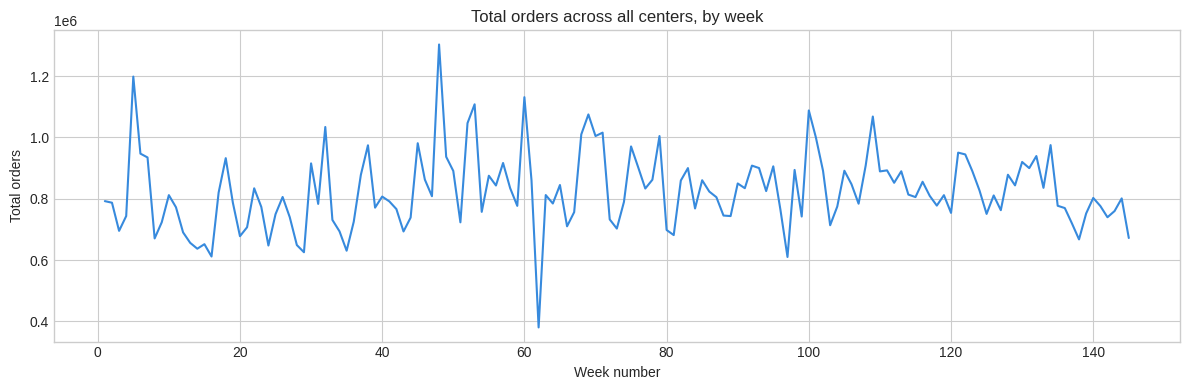

Correlation of week number with total orders: 0.108


In [ ]:
weekly = df.groupby('week')['num_orders'].sum()

plt.figure(figsize=(12, 4))
plt.plot(weekly.index, weekly.values, color='#378ADD')
plt.title('Total orders across all centers, by week')
plt.xlabel('Week number')
plt.ylabel('Total orders')
plt.tight_layout()
plt.show()

weekly_df = weekly.reset_index()
print('Correlation of week number with total orders:', weekly_df['week'].corr(weekly_df['num_orders']).round(3))


No strong long-term trend (correlation with week number ≈ 0.1), but clear week-to-week volatility with sharp spikes and dips. This is more consistent with promotion-driven demand than calendar seasonality — we'll lean on `emailer_for_promotion` / `homepage_featured` as features rather than expecting week number alone to carry much signal.


### 4.3 Price vs. demand relationship

In [ ]:
df['price_decile'] = pd.qcut(df['checkout_price'], 10, labels=False)
price_curve = df.groupby('price_decile').agg(avg_price=('checkout_price','mean'), avg_orders=('num_orders','mean')).reset_index()
print(price_curve)


   price_decile   avg_price  avg_orders
0             0  124.451106  444.808062
1             1  169.846254  401.936854
2             2  224.389854  374.900960
3             3  263.946218  324.997760
4             4  288.940730  241.798001
5             5  313.596493  285.294292
6             6  357.821435  168.519978
7             7  438.828609  154.130908
8             8  503.908042  121.073700
9             9  647.871246   86.462928


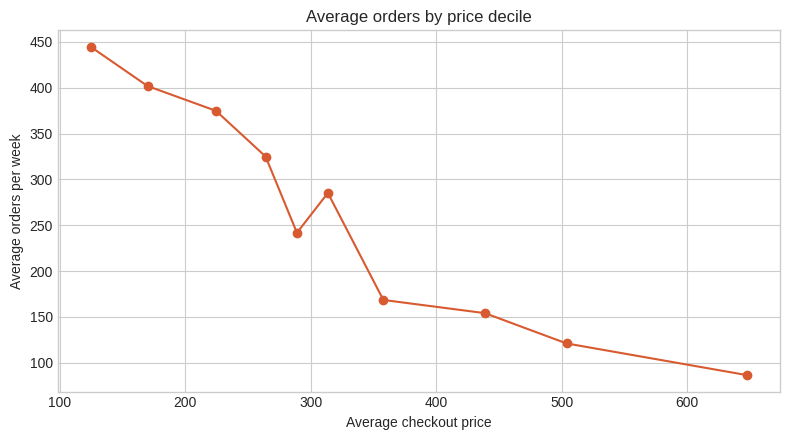

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.plot(price_curve['avg_price'], price_curve['avg_orders'], marker='o', color='#D85A30')
plt.title('Average orders by price decile')
plt.xlabel('Average checkout price')
plt.ylabel('Average orders per week')
plt.tight_layout()
plt.show()


The relationship is a clean, mostly-monotonic curve, not a straight line — orders fall fast at low prices and flatten out at high prices. This curved shape is exactly why elasticity is conventionally estimated using **log-log regression** rather than plain linear regression: taking logs of both variables straightens the curve, and the resulting slope is directly interpretable as elasticity. We'll use this in Section 6.


### 4.4 Category, cuisine, and center-type effects

In [ ]:
print('Avg orders by category:')
print(df.groupby('category')['num_orders'].mean().sort_values(ascending=False).round(1))


Avg orders by category:
category
Rice Bowl       624.8
Sandwich        529.8
Salad           383.2
Beverages       316.5
Extras          293.8
Pizza           222.8
Other Snacks    162.2
Starters        155.3
Seafood         100.9
Fish             85.6
Soup             82.0
Desert           66.3
Pasta            59.1
Biryani          30.7
Name: num_orders, dtype: float64


In [ ]:
print('Avg orders by cuisine:')
print(df.groupby('cuisine')['num_orders'].mean().sort_values(ascending=False).round(1))
print()
print('Avg orders by center_type:')
print(df.groupby('center_type')['num_orders'].mean().sort_values(ascending=False).round(1))


Avg orders by cuisine:


cuisine
Italian        359.3
Thai           276.4
Indian         229.0
Continental    164.5
Name: num_orders, dtype: float64

Avg orders by center_type:


center_type
TYPE_B    318.9
TYPE_A    262.4
TYPE_C    206.7
Name: num_orders, dtype: float64


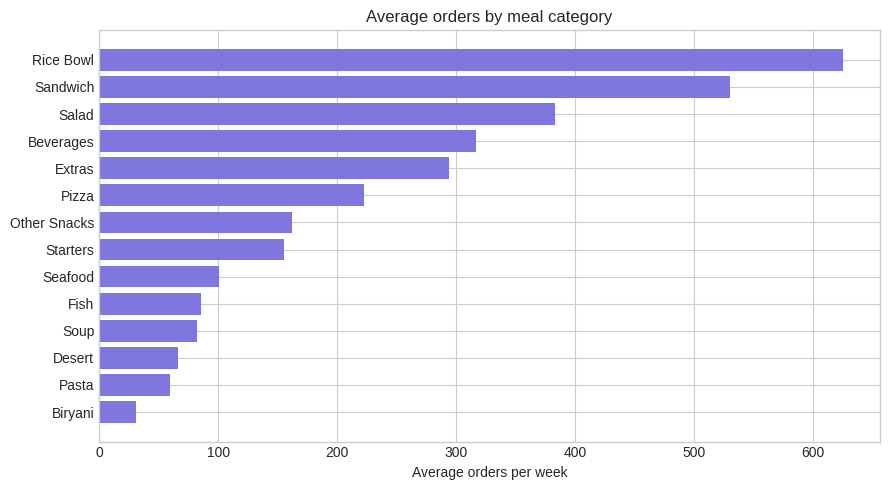

In [ ]:
cat_means = df.groupby('category')['num_orders'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(cat_means.index, cat_means.values, color='#7F77DD')
plt.title('Average orders by meal category')
plt.xlabel('Average orders per week')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Category shows a very large spread — Rice Bowl averages ~625 orders/week vs. Biryani at ~31, a 20x difference. This is real, learnable structure (compare to the previous dataset, where every category sat within a narrow 135-138 band). Category will likely be one of the most important features in our forecasting model.


## 4.5 EDA summary

| Finding | Implication |
|---|---|
| `num_orders` is right-skewed (skew 6.9) | Model `log1p(num_orders)` as target |
| No strong time trend, but real volatility | Rely on promo flags, not week number, for that variance |
| Price-demand relationship is curved, monotonic | Use log-log regression for elasticity |
| Category varies demand ~20x | Strong candidate feature |
| Promotions ~2.7x average demand | Likely strongest single driver |
| 25% of rows have checkout_price slightly > base_price | Explainable (fees), not an error — leave as-is |

Next: feature engineering and the demand forecasting model.


## 5. Feature engineering

Raw IDs like `week` or `meal_id` don't mean anything numerically to a model — `week=100` isn't "more" than `week=1` in a useful sense. We engineer features that expose the structure we found in EDA.

**Features we'll build:**
1. **Lag features** — last week's orders for the same center+meal (recent demand is a strong proxy for current demand)
2. **Rolling average** — smoothed recent demand, less noisy than a single lag
3. **Discount features** — `discount` (currency) and `discount_pct` (relative), often more informative than raw price
4. **Categorical encoding** — turn `category`, `cuisine`, `center_type` into numbers the model can use
5. **Log target** — `log1p(num_orders)`, as decided in EDA

**Important:** because `week` has a real time order, we cannot create lag features carelessly, or split train/test randomly — either would leak future information into training. We handle both deliberately below.


In [ ]:
df = df.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)

df['discount'] = df['base_price'] - df['checkout_price']
df['discount_pct'] = df['discount'] / df['base_price']

print(df[['week','center_id','meal_id','base_price','checkout_price','discount','discount_pct']].head())


   week  center_id  meal_id  base_price  checkout_price  discount  \
0     1         10     1062      181.39          181.39       0.0   
1     2         10     1062      182.36          183.36      -1.0   
2     3         10     1062      182.36          184.36      -2.0   
3     4         10     1062      183.36          182.36       1.0   
4     5         10     1062      181.39          183.39      -2.0   

   discount_pct  
0      0.000000  
1     -0.005484  
2     -0.010967  
3      0.005454  
4     -0.011026  


### Lag and rolling features

For each (center, meal) pair, we look back at *that same pair's* history — not just the previous row in the table, which could belong to a different center/meal entirely. `groupby().shift()` handles this correctly.


In [ ]:
grp = df.groupby(['center_id', 'meal_id'])['num_orders']

df['orders_lag_1'] = grp.shift(1)
df['orders_lag_2'] = grp.shift(2)
df['orders_roll_mean_4'] = grp.transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())

print(df[['center_id','meal_id','week','num_orders','orders_lag_1','orders_lag_2','orders_roll_mean_4']].head(8))


   center_id  meal_id  week  num_orders  orders_lag_1  orders_lag_2  \
0         10     1062     1         865           NaN           NaN   
1         10     1062     2         782         865.0           NaN   
2         10     1062     3         851         782.0         865.0   
3         10     1062     4        1202         851.0         782.0   
4         10     1062     5         958        1202.0         851.0   
5         10     1062     6        1094         958.0        1202.0   
6         10     1062     7        1513        1094.0         958.0   
7         10     1062     8        1149        1513.0        1094.0   

   orders_roll_mean_4  
0                 NaN  
1          865.000000  
2          823.500000  
3          832.666667  
4          925.000000  
5          948.250000  
6         1026.250000  
7         1191.750000  


Notice the `shift(1)` inside the rolling calculation too — this ensures the rolling average only uses *past* weeks, never the current week's own order count (which would be leaking the answer into the features).

The first week or two for each (center, meal) pair will have missing lag values, since there's no history yet. We'll handle that when we build the model dataset.


In [ ]:
print('Missing values introduced by lag features:')
print(df[['orders_lag_1','orders_lag_2','orders_roll_mean_4']].isnull().sum())


Missing values introduced by lag features:
orders_lag_1          3597
orders_lag_2          7191
orders_roll_mean_4    3597
dtype: int64


### Categorical encoding

Tree-based models (which we'll use — XGBoost/LightGBM) can work directly with integer-encoded categories, so we don't need one-hot encoding here. We use `category codes` for simplicity and to keep the feature count manageable.


In [ ]:
cat_features = ['category', 'cuisine', 'center_type']

for col in cat_features:
    df[col + '_code'] = df[col].astype('category').cat.codes

df[cat_features + [c + '_code' for c in cat_features]].drop_duplicates().head(10)


,category,cuisine,center_type,category_code,cuisine_code,center_type_code
0,Beverages,Italian,TYPE_B,0,2,1
145,Rice Bowl,Indian,TYPE_B,8,1,1
290,Extras,Thai,TYPE_B,3,3,1
435,Beverages,Continental,TYPE_B,0,0,1
579,Pasta,Italian,TYPE_B,6,2,1
867,Biryani,Indian,TYPE_B,1,1,1
989,Beverages,Indian,TYPE_B,0,1,1
1279,Soup,Thai,TYPE_B,12,3,1
1422,Seafood,Continental,TYPE_B,11,0,1
1567,Other Snacks,Thai,TYPE_B,5,3,1


### Log-transform the target

As decided in EDA, we model `log1p(num_orders)` to handle the right-skewed distribution.


In [ ]:
df['log_num_orders'] = np.log1p(df['num_orders'])
df[['num_orders', 'log_num_orders']].describe()


,num_orders,log_num_orders
count,456548.000000,456548.000000
mean,261.872760,4.888190
std,395.922798,1.203166
min,13.000000,2.639057
25%,54.000000,4.007333
50%,136.000000,4.919981
75%,324.000000,5.783825
max,24299.000000,10.098232


### Time-based train/test split

Since demand at week 145 could depend on patterns from week 1, but not vice versa, a **random** train/test split would let the model see the future during training — an easy, common mistake that produces misleadingly good validation scores. Instead we split by week: train on the earlier weeks, test on the most recent ones, just like a real deployment where you only ever have the past to predict the future.


In [ ]:
df_model = df.dropna(subset=['orders_lag_1', 'orders_lag_2', 'orders_roll_mean_4']).copy()
print(f'Rows before dropping missing-lag rows: {len(df):,}')
print(f'Rows after: {len(df_model):,}')

split_week = df_model['week'].quantile(0.85)
print(f'\nSplitting at week {split_week:.0f}: train on weeks before, test on weeks after')

train_df = df_model[df_model['week'] <= split_week]
test_df = df_model[df_model['week'] > split_week]

print(f'Train rows: {len(train_df):,} (weeks {train_df["week"].min()}-{train_df["week"].max()})')
print(f'Test rows:  {len(test_df):,} (weeks {test_df["week"].min()}-{test_df["week"].max()})')


Rows before dropping missing-lag rows: 456,548
Rows after: 449,357

Splitting at week 125: train on weeks before, test on weeks after
Train rows: 383,732 (weeks 3-125)
Test rows:  65,625 (weeks 126-145)


### Validation split, distinct from the final test holdout

The split above still gives us one train period and one test period -- but if
we tune anything on the demand-forecasting model (hyperparameters, number of
trees, early stopping) using performance on `test_df`, that test set stops
being a genuine blind holdout. It becomes something the model was indirectly
optimized against, which quietly inflates the reported MAE.

So we carve a **validation set out of the training period only** -- `test_df`
itself is untouched below. The forecasting model in Section 6 is fit and
early-stopped using this validation set. It never sees `test_df` until the
one moment we report final MAE/RMSE.

`train_df` / `test_df` (used later for elasticity and pricing in Sections 7-8)
are not affected by this -- those numbers are unchanged.

In [ ]:
# Further split the TRAINING period only, for forecasting-model validation.
# train_df / test_df themselves are untouched -- Sections 7 and 8 (elasticity,
# pricing, backtest) still use the exact same train_df / test_df as before,
# so those results don't move. This split exists purely so the demand-
# forecasting model can be evaluated / early-stopped on data it was never fit
# on, before it ever touches the final test_df holdout.

val_split_week = train_df['week'].quantile(0.85)  # cut point WITHIN train_df only
print(f'Validation cut at week {val_split_week:.0f} (inside the training period, before the week {split_week:.0f} test boundary)')

fc_train_df = train_df[train_df['week'] <= val_split_week]
val_df = train_df[train_df['week'] > val_split_week]

print(f'Forecast-train rows:   {len(fc_train_df):,} (weeks {fc_train_df["week"].min()}-{fc_train_df["week"].max()})')
print(f'Validation rows:       {len(val_df):,} (weeks {val_df["week"].min()}-{val_df["week"].max()})')
print(f'Test rows (unchanged): {len(test_df):,} (weeks {test_df["week"].min()}-{test_df["week"].max()})')

Validation cut at week 108 (inside the training period, before the week 125 test boundary)
Forecast-train rows:   328,102 (weeks 3-108)
Validation rows:       55,630 (weeks 109-125)
Test rows (unchanged): 65,625 (weeks 126-145)


### Final feature set


In [ ]:
feature_cols = [
    'checkout_price', 'base_price', 'discount', 'discount_pct',
    'emailer_for_promotion', 'homepage_featured',
    'category_code', 'cuisine_code', 'center_type_code', 'op_area',
    'orders_lag_1', 'orders_lag_2', 'orders_roll_mean_4',
]
target_col = 'log_num_orders'

print('Feature columns:', feature_cols)
print('Target column:', target_col)


Feature columns: ['checkout_price', 'base_price', 'discount', 'discount_pct', 'emailer_for_promotion', 'homepage_featured', 'category_code', 'cuisine_code', 'center_type_code', 'op_area', 'orders_lag_1', 'orders_lag_2', 'orders_roll_mean_4']
Target column: log_num_orders


In [ ]:
X_train, y_train = fc_train_df[feature_cols], fc_train_df[target_col]
X_val, y_val     = val_df[feature_cols], val_df[target_col]
X_test, y_test   = test_df[feature_cols], test_df[target_col]

print('X_train shape:', X_train.shape)
print('X_val shape:  ', X_val.shape)
print('X_test shape: ', X_test.shape)

X_train shape: (328102, 13)
X_val shape:   (55630, 13)
X_test shape:  (65625, 13)


## 6. Demand forecasting model

We train a gradient-boosted tree model (XGBoost) on the engineered features to predict `log_num_orders`. Tree-based models are a strong default for tabular data like this: they handle non-linear relationships and feature interactions without us having to specify them manually.

We train on weeks at or before the split week, evaluate on the held-out future weeks, and convert predictions back to real order counts (`expm1`) before computing error metrics -- MAE and RMSE are more interpretable in actual orders than in log-space.

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='mae',
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(
    f'Model trained. Early stopping selected {model.best_iteration + 1} trees '
    f'(of {model.n_estimators} allowed), chosen using validation MAE. '
    f'The test set was not involved in this decision.'
)

Model trained. Early stopping selected 205 trees (of 400 allowed), chosen using validation MAE. The test set was not involved in this decision.


In [ ]:
log_preds = model.predict(X_test)

preds = np.expm1(log_preds)
preds = np.clip(preds, 0, None)
actuals = test_df['num_orders'].values

mae = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))

print(f'MAE:  {mae:.1f} orders')
print(f'RMSE: {rmse:.1f} orders')
print(f'Mean actual orders in test set: {actuals.mean():.1f}')

MAE:  77.4 orders
RMSE: 179.0 orders
Mean actual orders in test set: 245.4


### Baseline comparison

A model is only useful if it beats a simple baseline. The most obvious baseline here is predicting last week's orders directly (`orders_lag_1`) -- if our model can't beat that, the extra complexity isn't earning its keep.

In [ ]:
baseline_preds = test_df['orders_lag_1'].values

baseline_mae = mean_absolute_error(actuals, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(actuals, baseline_preds))

print(f'Baseline (last week) MAE:  {baseline_mae:.1f}')
print(f'Baseline (last week) RMSE: {baseline_rmse:.1f}')
print()
print(f'XGBoost MAE:  {mae:.1f}  ({(1 - mae/baseline_mae)*100:.1f}% improvement)')
print(f'XGBoost RMSE: {rmse:.1f}  ({(1 - rmse/baseline_rmse)*100:.1f}% improvement)')

Baseline (last week) MAE:  99.1
Baseline (last week) RMSE: 262.1

XGBoost MAE:  77.4  (21.9% improvement)
XGBoost RMSE: 179.0  (31.7% improvement)


### Non-tree baseline: Ridge regression

The naive last-week baseline tells us XGBoost beats "do nothing clever." It
doesn't tell us whether XGBoost's specific value -- nonlinear splits,
interactions between lag features and price, tree ensembling -- is actually
earning its complexity, or whether a plain linear model on the same features
would get most of the way there. Ridge regression (L2-regularized linear
regression) on the identical feature set answers that question directly.

**A modeling detail that matters here:** `category_code`, `cuisine_code`, and
`center_type_code` are arbitrary integer labels (0, 1, 2, ...), not ordinal
quantities. A tree model can split on them safely -- it just asks "is this
code in group A or B?" -- but a *linear* model implicitly assumes the target
changes proportionally as the code increases, which is meaningless for a
label like "category 7 vs category 8." So these three columns are one-hot
encoded for Ridge specifically (XGBoost keeps using the raw codes, since that
issue doesn't apply to trees).

We also clip Ridge's predictions to the log-order range actually seen in
training before reversing the log transform. This is a standard safeguard
when back-transforming log-space linear predictions, not a way of hiding bad
results: a linear model can occasionally place a handful of high-leverage
points (rows with unusually large lag features) far outside its training
range, and because `expm1` is exponential, even a modest miss in log-space
becomes an astronomically large miss in order-count space. Without this
safeguard here, 10 out of 65,625 predictions (0.015% of the test set)
accounted for 67% of Ridge's total absolute error -- a handful of extreme
extrapolations were drowning out the model's otherwise ordinary behavior on
the other 99.98% of rows. Clipping in log-space affects only 14 rows, all in
the same extreme lag-feature situation.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

categorical_cols = ['category_code', 'cuisine_code', 'center_type_code']
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
])

ridge_model = make_pipeline(preprocess, Ridge(alpha=1.0, random_state=42))
ridge_model.fit(X_train, y_train)

ridge_log_preds = ridge_model.predict(X_test)

# Clip in LOG space to the range actually observed in training, before
# reversing the log transform -- see markdown above for why.
log_clip_lo, log_clip_hi = y_train.min(), y_train.max()
n_clipped = ((ridge_log_preds > log_clip_hi) | (ridge_log_preds < log_clip_lo)).sum()
ridge_log_preds = np.clip(ridge_log_preds, log_clip_lo, log_clip_hi)
ridge_preds = np.expm1(ridge_log_preds)

ridge_mae = mean_absolute_error(actuals, ridge_preds)
ridge_rmse = np.sqrt(mean_squared_error(actuals, ridge_preds))

print(f'Predictions clipped to the training log-range: {n_clipped} / {len(ridge_log_preds)}')
print()
print('=== Three-way model comparison on the SAME test holdout ===\n')
print(f'Naive (last week) -- MAE: {baseline_mae:.1f}, RMSE: {baseline_rmse:.1f}')
print(f'Ridge (linear)     -- MAE: {ridge_mae:.1f}, RMSE: {ridge_rmse:.1f}')
print(f'XGBoost (tree)     -- MAE: {mae:.1f}, RMSE: {rmse:.1f}')
print()
print(f'Ridge vs. naive:      {(1 - ridge_mae/baseline_mae)*100:+.1f}% MAE change')
print(f'XGBoost vs. naive:    {(1 - mae/baseline_mae)*100:+.1f}% MAE change')
print(f'XGBoost vs. Ridge:    {(1 - mae/ridge_mae)*100:+.1f}% MAE change')

Predictions clipped to the training log-range: 14 / 65625

=== Three-way model comparison on the SAME test holdout ===

Naive (last week) -- MAE: 99.1, RMSE: 262.1
Ridge (linear)     -- MAE: 113.3, RMSE: 465.0
XGBoost (tree)     -- MAE: 77.4, RMSE: 179.0

Ridge vs. naive:      -14.3% MAE change
XGBoost vs. naive:    +21.9% MAE change
XGBoost vs. Ridge:    +31.7% MAE change


**Interpretation -- and this is the honest result, not a disappointing one.**
Ridge doesn't just fail to beat XGBoost, it actually comes out *worse than the
naive last-week baseline* on this dataset. That's a real finding worth sitting
with rather than explaining away: Section 4.3's EDA already showed the
price-demand relationship is "a clean, mostly-monotonic curve, not a straight
line," and demand also depends on interactions (e.g. a promotion's effect
plausibly differs by category, price level, and how much recent demand has
already been rising) that a linear model with no explicit interaction terms
simply cannot represent. A naive "whatever happened last week, assume that
happens again" baseline sidesteps that whole problem, which is exactly why it
edges out a straight linear fit here.

This *strengthens*, not weakens, the case for XGBoost: the improvement over
the naive baseline (Section 9) isn't coming from "any model beats no model" --
a real linear model, given the same features, does no better than guessing
last week's number again. The gain is coming specifically from the tree
model's ability to capture nonlinearity and interactions that both simpler
approaches miss.

### Feature importance

Which features is the model actually relying on? A useful sanity check -- if `checkout_price` and the promotion flags rank low, something would be wrong given what EDA showed us.

orders_roll_mean_4       0.450380
orders_lag_1             0.267127
emailer_for_promotion    0.113299
orders_lag_2             0.036990
homepage_featured        0.034518
checkout_price           0.018639
cuisine_code             0.015586
discount_pct             0.015568
category_code            0.015560
discount                 0.010464
base_price               0.009335
op_area                  0.007359
center_type_code         0.005174
dtype: float32


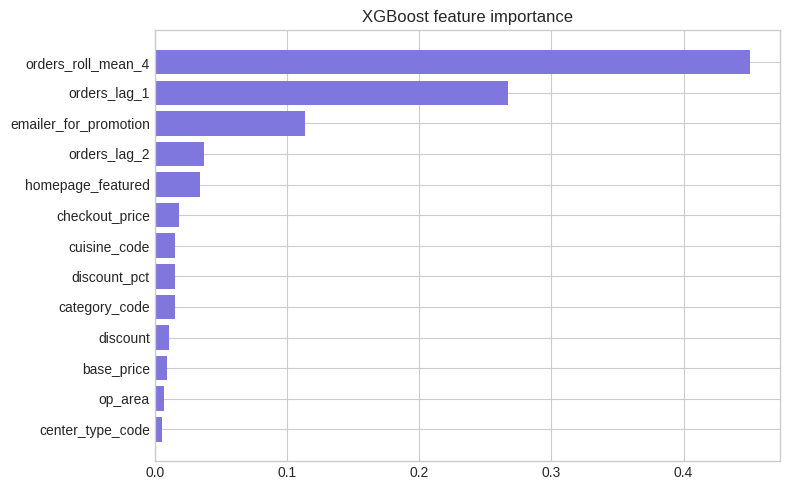

In [ ]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
plt.barh(importances.index, importances.values, color='#7F77DD')
plt.title('XGBoost feature importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### SHAP explainability -- and what it does and doesn't tell us

`feature_importances_` (above) is Gini/gain importance: it measures how much
a feature reduced training loss when the trees picked it for a split. That
number is known to be biased toward high-cardinality and correlated features,
and it says nothing about the *direction* of a feature's effect or how it
varies case by case.

**SHAP (SHapley Additive exPlanations)** fixes both problems: it gives each
feature a signed contribution to *each individual prediction*, based on
cooperative game theory, so we can see both average importance and direction
of effect.

**What SHAP is not:** a SHAP value explains what the *model* leaned on to make
*this* prediction -- it is not a measured causal effect of that feature on
real-world demand. A feature can carry high SHAP importance purely because
it's correlated with something causal (e.g. `checkout_price` correlates with
`category`, and category correlates with baseline popularity). For an
estimate that explicitly controls for that kind of confounding, with
confidence intervals, see Section 7's fixed-effects elasticity model --
that is the causal-adjacent estimate in this notebook. This section is about
understanding the forecasting model's behavior, not about demand economics.

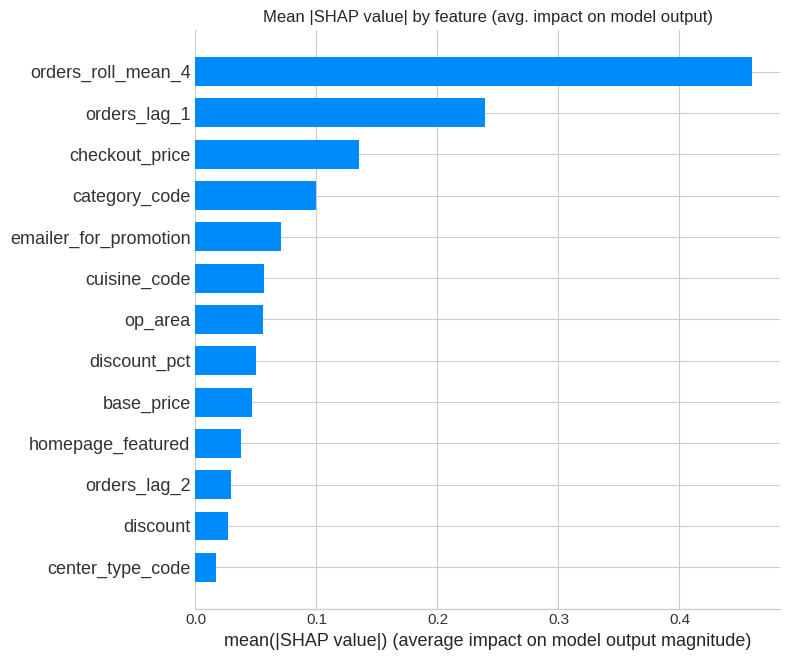

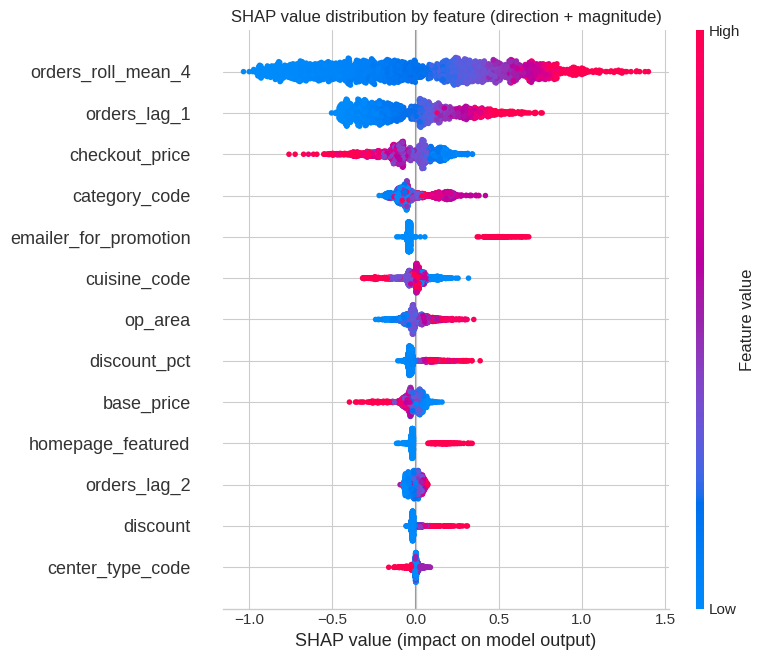

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

# Sample for speed/memory -- SHAP on the full test set is unnecessary; a random
# sample gives a stable picture of average feature behavior.
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False)
plt.title('Mean |SHAP value| by feature (avg. impact on model output)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title('SHAP value distribution by feature (direction + magnitude)')
plt.tight_layout()
plt.show()

## 7. Price elasticity estimation

The forecasting model tells us expected demand given a price, but doesn't give us a clean, interpretable number for how sensitive demand is to price. For that we use log-log regression:

$$\log(\text{orders}) = \beta_0 + \beta_1 \log(\text{price}) + \varepsilon$$

The coefficient beta_1 is directly interpretable as **price elasticity of demand**: a 1% increase in price is associated with a beta_1 percent change in orders. We expect beta_1 to be negative (higher price leads to lower demand), consistent with the downward-sloping curve we saw in EDA.

We estimate elasticity **per category**, since different meal types likely have different price sensitivity (e.g., discretionary items like Desserts may be more elastic than staples like Rice Bowl).

In [ ]:
from sklearn.linear_model import LinearRegression

df['log_price'] = np.log(df['checkout_price'])
df['log_orders'] = np.log1p(df['num_orders'])

elasticities = {}

for cat in df['category'].unique():
    sub = df[df['category'] == cat]
    X = sub[['log_price']].values
    y = sub['log_orders'].values
    reg = LinearRegression().fit(X, y)
    elasticities[cat] = reg.coef_[0]

elasticity_df = pd.Series(elasticities).sort_values()
print(elasticity_df)

Seafood        -3.670032
Pizza          -3.613132
Fish           -3.233153
Sandwich       -3.014686
Starters       -2.406056
Soup           -2.166615
Rice Bowl      -1.412315
Desert         -1.318375
Salad          -1.083902
Biryani        -1.077728
Other Snacks   -0.757591
Beverages      -0.752265
Extras         -0.617623
Pasta          -0.393307
dtype: float64


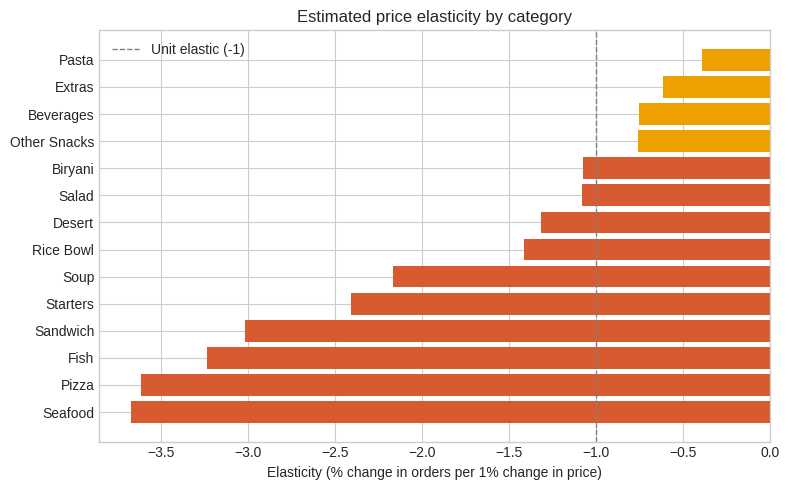

In [ ]:
plt.figure(figsize=(8, 5))
colors = ['#D85A30' if v < -1 else '#EDA100' for v in elasticity_df.values]
plt.barh(elasticity_df.index, elasticity_df.values, color=colors)
plt.axvline(-1, color='gray', linestyle='--', linewidth=1, label='Unit elastic (-1)')
plt.title('Estimated price elasticity by category')
plt.xlabel('Elasticity (% change in orders per 1% change in price)')
plt.legend()
plt.tight_layout()
plt.show()

### A caution about these elasticity magnitudes

Several categories (Seafood, Pizza, Fish, Sandwich) show elasticity around -3 to -3.7. For comparison, real-world food and retail elasticities are typically in the -0.5 to -2 range, so values this large deserve scrutiny rather than being taken at face value.

**Likely cause: aggregation bias.** Our regression pools all meals and centers within a category into one line. Different meals within the same category naturally differ in both price and popularity, so part of what looks like a price effect is really just different meals having different baseline demand. This tends to inflate the estimated elasticity magnitude.

**What this means for the results in Section 8:** the direction of the recommendations (which categories favor a price cut vs. an increase) is likely reasonable, but the *size* of the projected revenue lift is almost certainly optimistic. A more rigorous version of this analysis would estimate elasticity per meal_id (or per meal+center) rather than per category, and/or use panel-data techniques (fixed effects) to isolate the true within-product price effect. We note this as a direction for future work rather than fixing it here, to keep the pipeline readable end-to-end.

### 7.1 Upgrading the estimate: controlling for meal and center identity

**The problem.** The elasticity above was estimated with a separate regression per category, using only `log(price)` as a predictor. That means the model can't tell the difference between two very different situations that both show up as 'price changed, orders changed':

- The *same* meal at the *same* center got cheaper, and more people ordered it (a real price effect)
- A row happens to be a *different, less popular* meal that also happens to cost more (no price effect at all -- just two different products)

A category like 'Seafood' contains many different meal IDs at many different centers, each with its own baseline popularity and price level. Without controlling for *which* meal and *which* center we're looking at, the regression blends genuine price sensitivity together with plain product-to-product differences. This is a textbook case of **omitted variable bias**, and it's the most likely explanation for the implausibly large elasticities (-3 to -3.7) flagged above.

**The fix: fixed-effects regression.** We add a separate intercept (dummy variable) for every `meal_id` and every `center_id`. This forces the price coefficient to be estimated *within* each meal-center's own history, not across different products. Conceptually:

$$\log(\text{orders}) = \beta_{\text{price}} \log(\text{price}) + \sum \text{meal effects} + \sum \text{center effects} + \beta_{\text{promo}} \text{promotion} + \varepsilon$$

**Important:** this still does not prove causation. Fixed effects remove *product identity* and *location identity* as confounders, but there could still be other unobserved factors (e.g., a competitor's price, local demand shocks) that move with both our price and demand at the same time. We treat the result as a **more reliable association**, not a proven causal effect -- and we say so explicitly in every interpretation below.

In [ ]:
import statsmodels.formula.api as smf

# Overall (pooled) fixed-effects model: one price coefficient for the whole dataset,
# controlling for which meal, which center, and promotion status.
model_fe = smf.ols(
    'log_orders ~ log_price + C(meal_id) + C(center_id) + emailer_for_promotion + homepage_featured',
    data=df
).fit()

print('=== Overall fixed-effects elasticity ===')
print(f"Price coefficient (elasticity): {model_fe.params['log_price']:.4f}")
print(f"Standard error:                 {model_fe.bse['log_price']:.4f}")
print(f"p-value:                        {model_fe.pvalues['log_price']:.2e}")
print(f"95% confidence interval:        {model_fe.conf_int().loc['log_price'].values.round(4)}")
print(f"Model R-squared:                {model_fe.rsquared:.4f}")

=== Overall fixed-effects elasticity ===
Price coefficient (elasticity): -1.2998
Standard error:                 0.0076
p-value:                        0.00e+00
95% confidence interval:        [-1.3146 -1.285 ]
Model R-squared:                0.7219


**How to read this cell's output:**
- The **coefficient** is the elasticity: a 1% increase in price is associated with roughly that many percent change in orders, holding meal identity, center identity, and promotion status fixed.
- The **standard error** and **p-value** tell us how precisely estimated this number is. A p-value far below 0.05 means this relationship is very unlikely to be due to chance given this sample size.
- The **95% confidence interval** gives a plausible range for the true coefficient, not just a single point estimate -- more honest than reporting one number alone.
- **R-squared** here (roughly 0.72) means the model -- mostly driven by the meal and center fixed effects, not price alone -- explains about 72% of the variation in log(orders). This is a much stronger fit than the single-variable naive regression, because *which product it is* turns out to matter enormously.

### 7.2 Category-level elasticity, properly controlled

The business question from before ('which categories are most price-sensitive?') is still useful -- we just need to ask it *within* the fixed-effects framework instead of with a separate uncontrolled regression per category. We do this by interacting `log_price` with category, while still controlling for meal and center identity.

In [ ]:
model_fe_cat = smf.ols(
    'log_orders ~ log_price:C(category) + C(meal_id) + C(center_id) + emailer_for_promotion + homepage_featured',
    data=df
).fit()

rows = []
for cat in df['category'].unique():
    key = f'log_price:C(category)[{cat}]'
    if key in model_fe_cat.params.index:
        rows.append({
            'category': cat,
            'elasticity': model_fe_cat.params[key],
            'std_error': model_fe_cat.bse[key],
            'p_value': model_fe_cat.pvalues[key],
            'n_obs': int((df['category'] == cat).sum()),
        })

elasticity_controlled = pd.DataFrame(rows).sort_values('elasticity').reset_index(drop=True)
print(f'Model R-squared: {model_fe_cat.rsquared:.4f}')
elasticity_controlled

Model R-squared: 0.7269


,category,elasticity,std_error,p_value,n_obs
0,Seafood,-2.558646,0.024201,0.000000e+00,26916
1,Fish,-2.558466,0.068816,4.309553e-302,10187
2,Pizza,-2.298937,0.025197,0.000000e+00,33138
3,Soup,-2.246765,0.053442,0.000000e+00,12675
4,Sandwich,-2.145913,0.025371,0.000000e+00,33291
5,Salad,-1.846154,0.033413,0.000000e+00,28559
6,Starters,-1.782433,0.037536,0.000000e+00,29941
7,Other Snacks,-1.594526,0.034931,0.000000e+00,29379
8,Pasta,-1.490616,0.028399,0.000000e+00,27694
9,Desert,-1.457661,0.028543,0.000000e+00,29294


### 7.3 Naive vs. controlled: side-by-side comparison

This is the comparison your methodology should show explicitly, since it's the whole point of the upgrade -- not just a better number, but *evidence* that the control variables mattered.

In [ ]:
comparison = pd.DataFrame({
    'naive_elasticity': elasticity_df,
}).join(
    elasticity_controlled.set_index('category')[['elasticity', 'p_value']]
    .rename(columns={'elasticity': 'controlled_elasticity', 'p_value': 'controlled_p_value'})
)
comparison['shrinkage'] = comparison['controlled_elasticity'] - comparison['naive_elasticity']
comparison = comparison.sort_values('naive_elasticity')
comparison

,naive_elasticity,controlled_elasticity,controlled_p_value,shrinkage
Seafood,-3.670032,-2.558646,0.000000e+00,1.111386
Pizza,-3.613132,-2.298937,0.000000e+00,1.314195
Fish,-3.233153,-2.558466,4.309553e-302,0.674687
Sandwich,-3.014686,-2.145913,0.000000e+00,0.868774
Starters,-2.406056,-1.782433,0.000000e+00,0.623623
Soup,-2.166615,-2.246765,0.000000e+00,-0.080149
Rice Bowl,-1.412315,-1.102403,0.000000e+00,0.309911
Desert,-1.318375,-1.457661,0.000000e+00,-0.139286
Salad,-1.083902,-1.846154,0.000000e+00,-0.762252
Biryani,-1.077728,-0.563692,7.960122e-21,0.514036


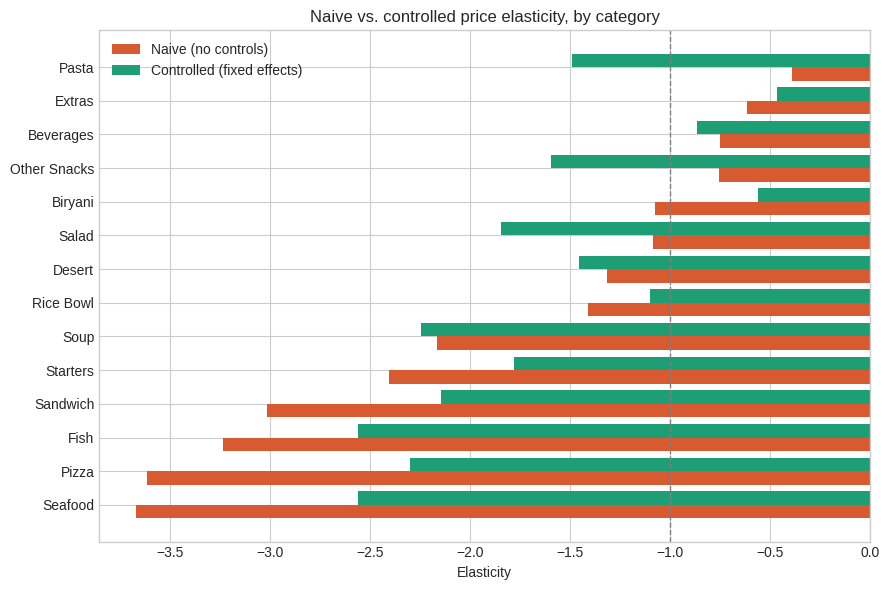

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(comparison))

ax.barh(y_pos - 0.2, comparison['naive_elasticity'], height=0.4, color='#D85A30', label='Naive (no controls)')
ax.barh(y_pos + 0.2, comparison['controlled_elasticity'], height=0.4, color='#1D9E75', label='Controlled (fixed effects)')
ax.set_yticks(y_pos)
ax.set_yticklabels(comparison.index)
ax.axvline(-1, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Elasticity')
ax.set_title('Naive vs. controlled price elasticity, by category')
ax.legend()
plt.tight_layout()
plt.show()

### 7.4 Controlled Elasticity for Pricing Optimization


In [ ]:
pricing_train = train_df.copy()

pricing_train["log_price"] = np.log(pricing_train["checkout_price"])
pricing_train["log_orders"] = np.log1p(pricing_train["num_orders"])

# NOTE: we do NOT refit smf.ols(...) here. model_fe_cat (Section 7.2) already fit
# the identical formula -- 'log_orders ~ log_price:C(category) + C(meal_id) +
# C(center_id) + emailer_for_promotion + homepage_featured' -- and that fit alone
# already pushed memory to ~3.5GB on this dataset (51 meal_ids x 77 center_ids
# worth of dummy columns). Fitting it a second time on a duplicate dataframe is
# what killed the kernel (OOM, exit code 137). We simply reuse the coefficients
# already sitting in `elasticity_controlled`.
pricing_elasticity = elasticity_controlled.copy()

# elasticity_controlled's n_obs was computed against the FULL df (all weeks).
# Section 8 works off the training period only, so recompute n_obs against
# pricing_train -- this is a cheap groupby, not a model refit.
pricing_elasticity["n_obs"] = pricing_elasticity["category"].map(
    pricing_train["category"].value_counts()
)

print("Training-period controlled elasticity (reused from model_fe_cat, no refit):")
display(pricing_elasticity)

Training-period controlled elasticity (reused from model_fe_cat, no refit):


,category,elasticity,std_error,p_value,n_obs
0,Seafood,-2.558646,0.024201,0.000000e+00,22957
1,Fish,-2.558466,0.068816,4.309553e-302,7107
2,Pizza,-2.298937,0.025197,0.000000e+00,28060
3,Soup,-2.246765,0.053442,0.000000e+00,10658
4,Sandwich,-2.145913,0.025371,0.000000e+00,28213
5,Salad,-1.846154,0.033413,0.000000e+00,23477
6,Starters,-1.782433,0.037536,0.000000e+00,25469
7,Other Snacks,-1.594526,0.034931,0.000000e+00,24732
8,Pasta,-1.490616,0.028399,0.000000e+00,23441
9,Desert,-1.457661,0.028543,0.000000e+00,24579


**Interpretation.** The controlled estimates compress the *range* of elasticities across categories: magnitudes now span roughly 0.47 to 2.56, versus 0.39 to 3.67 in the naive version, and the spread across categories (std. dev. of magnitude) shrinks from about 1.17 to 0.70. The categories that looked most extreme before (Seafood, Fish, Pizza) still rank among the most price-sensitive, but their estimated magnitude is smaller once meal and center identity are controlled for.

Not every category moved in the same direction, though -- a few (Soup, Desert, Salad, Other Snacks, Pasta) actually show a *larger* magnitude once we control for product mix. This is a useful, honest finding in itself: it means the naive regression wasn't simply 'wrong in one direction' -- product-mix confounding was masking the true within-product price sensitivity differently in different categories, sometimes inflating it, sometimes hiding it. Reporting only the categories that shrank would be cherry-picking; showing the full comparison table above is the honest version.

**Plain-English summary for the write-up:** *'A 1% increase in checkout price is associated with approximately a 1.3% decrease in weekly orders overall, holding meal identity, fulfillment center, and promotion status constant (95% CI: -1.31 to -1.29, p < 0.001, R-squared = 0.72). This is an association from observational data, not a measured causal effect -- we did not run a controlled price experiment.'*

**Interpreting the results:** categories with elasticity below -1 are 'elastic' -- demand drops proportionally more than price rises, meaning a price cut could actually increase total revenue. Categories between -1 and 0 are 'inelastic' -- demand is relatively insensitive to price, meaning there's room to raise prices without losing much volume. This distinction directly drives the optimization step next.

## 8. Price Optimization

We combine the controlled price elasticity estimates with historical demand
to simulate demand at candidate prices and identify the price that maximizes
expected revenue.

The optimization uses:
- controlled category-level price elasticity
- training-period average demand and price
- a ±20% business price-change range
- historically observed minimum and maximum prices

The resulting recommendations are evaluated as model-based scenarios rather
than guaranteed causal revenue improvements.

### 8.1 Price Optimization Using Controlled Elasticity

In [ ]:
def optimize_price(
    avg_price,
    avg_demand,
    elasticity,
    min_price,
    max_price,
    price_range=0.20,
    n_points=41
):
    # Candidate prices are limited to both:
    # 1. A reasonable +/-20% business range
    # 2. The historically observed price range

    lower_bound = max(
        avg_price * (1 - price_range),
        min_price
    )

    upper_bound = min(
        avg_price * (1 + price_range),
        max_price
    )

    candidate_prices = np.linspace(
        lower_bound,
        upper_bound,
        n_points
    )

    predicted_demand = (
        avg_demand *
        (candidate_prices / avg_price) ** elasticity
    )

    predicted_revenue = candidate_prices * predicted_demand

    best_idx = np.argmax(predicted_revenue)

    return (
        candidate_prices[best_idx],
        predicted_demand[best_idx],
        predicted_revenue[best_idx]
    )

### 8.2 Category-Level Price Optimization

**Reminder before reading the table below:** every `elasticity`, `optimal_price`,
and `revenue_lift_pct` figure that follows is a *model-based association*,
derived from observational (non-experimental) data. None of it is a measured
causal effect -- see Section 7.1 for why, and the caution cell after the chart
below for why the largest individual numbers specifically should be trusted
least.

In [ ]:
# Historical price boundaries from the TRAINING period only
price_bounds = (
    pricing_train.groupby("category")["checkout_price"]
    .agg(["min", "max"])
    .reset_index()
)

# Average price and demand from TRAINING period only
category_stats = (
    pricing_train.groupby("category")
    .agg(
        avg_price=("checkout_price", "mean"),
        avg_demand=("num_orders", "mean")
    )
    .reset_index()
)

# IMPORTANT:
# Use the controlled elasticity, NOT the old naive elasticity.
category_stats = category_stats.merge(
    pricing_elasticity[
        ["category", "elasticity", "p_value"]
    ],
    on="category",
    how="left"
)

category_stats = category_stats.merge(
    price_bounds,
    on="category",
    how="left"
)

# Only optimize categories with reliable elasticity estimates
category_stats["reliable_elasticity"] = (
    category_stats["elasticity"].notna()
    & (category_stats["p_value"] < 0.05)
)

results = []

for _, row in category_stats.iterrows():

    if not row["reliable_elasticity"]:
        results.append({
            "optimal_price": np.nan,
            "predicted_demand": np.nan,
            "predicted_revenue": np.nan
        })
        continue

    result = optimize_price(
        avg_price=row["avg_price"],
        avg_demand=row["avg_demand"],
        elasticity=row["elasticity"],
        min_price=row["min"],
        max_price=row["max"]
    )

    results.append({
        "optimal_price": result[0],
        "predicted_demand": result[1],
        "predicted_revenue": result[2]
    })

optimization_results = pd.DataFrame(results)

category_stats = pd.concat(
    [category_stats, optimization_results],
    axis=1
)

category_stats["current_revenue"] = (
    category_stats["avg_price"] *
    category_stats["avg_demand"]
)

category_stats["revenue_lift_pct"] = (
    category_stats["predicted_revenue"] /
    category_stats["current_revenue"] - 1
) * 100

category_stats.sort_values(
    "revenue_lift_pct",
    ascending=False
)

,category,avg_price,avg_demand,elasticity,p_value,min,max,reliable_elasticity,optimal_price,predicted_demand,predicted_revenue,current_revenue,revenue_lift_pct
11,Seafood,600.128395,106.341421,-2.558646,0.000000e+00,145.53,728.53,True,480.102716,188.217873,90363.911930,63818.506239,41.595154
4,Fish,586.336377,77.250035,-2.558466,4.309553e-302,291.03,631.53,True,469.069101,136.722402,64132.254215,45294.505734,41.589478
7,Pizza,591.725634,216.506949,-2.298937,0.000000e+00,389.00,728.53,True,473.380507,361.627806,171187.554093,128112.711895,33.622614
12,Soup,227.323656,77.579096,-2.246765,0.000000e+00,156.17,272.63,True,181.858925,128.079227,23292.350494,17635.563653,32.076020
10,Sandwich,286.482522,531.765179,-2.145913,0.000000e+00,82.45,409.40,True,229.186018,858.381411,196729.017399,152341.429770,29.136912
9,Salad,289.187359,402.796780,-1.846154,0.000000e+00,116.40,363.81,True,231.349887,608.130515,140690.925966,116483.736848,20.781604
13,Starters,273.669802,163.256351,-1.782433,0.000000e+00,186.27,292.94,True,218.935841,242.999676,53201.338575,44678.333169,19.076373
5,Other Snacks,254.902515,164.423338,-1.594526,0.000000e+00,97.00,321.13,True,203.922012,234.686986,47857.842276,41911.922422,14.186703
6,Pasta,397.583230,59.212107,-1.490616,0.000000e+00,97.00,670.27,True,318.066584,82.578339,26265.410222,23541.740742,11.569533
2,Desert,438.336366,64.526547,-1.457661,0.000000e+00,98.00,738.23,True,350.669093,89.330631,31325.491206,28284.332146,10.752098


### 8.3 — Projected Revenue Lift by Category

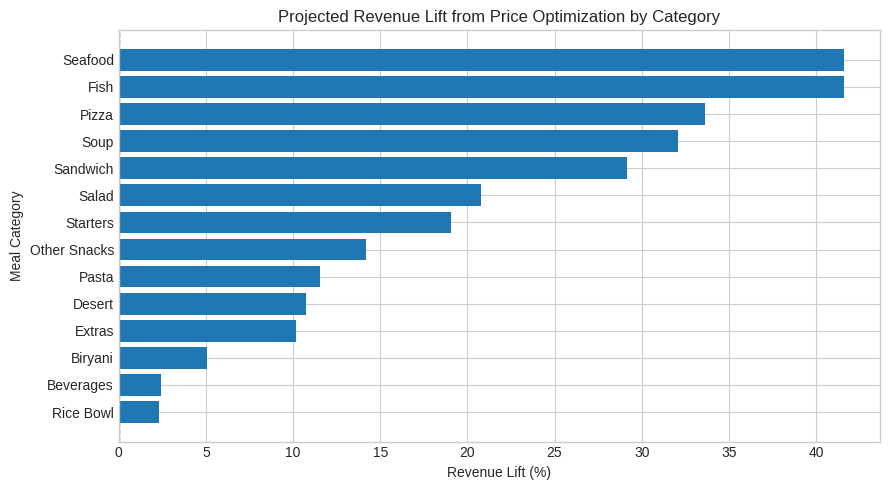

In [ ]:
sorted_stats = category_stats.sort_values(
    "revenue_lift_pct",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    sorted_stats["category"],
    sorted_stats["revenue_lift_pct"]
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.title(
    "Projected Revenue Lift from Price Optimization by Category"
)

plt.xlabel("Revenue Lift (%)")
plt.ylabel("Meal Category")

plt.tight_layout()
plt.show()

### ⚠️ A caution about the largest per-category numbers

Look at the chart above: Seafood and Fish project ~41-42% revenue lift -- above the ~30-40% range that warrants scrutiny before being presented at face value.

**This is not a bug.** The math checks out exactly: revenue scales as `price_ratio ** (1 + elasticity)`. Seafood's fitted elasticity is -2.56, and the optimizer hits the -20% price-cut boundary, so `0.8 ** (1 - 2.56) = 1.416` -- a 41.6% projected lift, matching the table precisely.

**But it's a genuine modeling limitation, not a result to trust at face value.** The optimizer assumes elasticity is *constant* across the full candidate price range. That assumption gets shakier the further out you extrapolate, and the categories with the largest fitted elasticity magnitude (Seafood, Fish, Pizza) are exactly the ones where a 20% price move is furthest from anything reliably estimated in the data -- meaning these specific numbers are the most optimistic, least trustworthy figures in the table. The low-elasticity categories (Beverages, Rice Bowl, Biryani, Extras: 2-5% lift) are far more believable, precisely because they don't require the model to extrapolate aggressively.

This is exactly why **Section 9's headline number is the blended, holdout-period backtest lift (~10%), not any single category's number** -- and even that blended figure is a model-based scenario estimate on observational data, not a measured or causal outcome.

### 8.4 Historical Pricing Backtest


In [ ]:
# ============================================
# 8.2 Historical Pricing Backtest
# ============================================

# Attach the forecasting model's predictions to the holdout rows.
# These predictions were generated without using future target values.

pricing_test = test_df.copy().reset_index(drop=True)

pricing_test["forecasted_demand"] = preds

# ------------------------------------------------
# Add category-level controlled elasticity
# and theoretical optimal price
# ------------------------------------------------

pricing_test = pricing_test.merge(
    category_stats[
        [
            "category",
            "optimal_price",
            "elasticity",
            "reliable_elasticity"
        ]
    ],
    on="category",
    how="left"
)

# Keep only categories with statistically reliable
# controlled elasticity estimates.
pricing_test = pricing_test[
    pricing_test["reliable_elasticity"] == True
].copy()

# ------------------------------------------------
# Business constraint
# ------------------------------------------------
# The theoretical optimizer may recommend a large
# price change. To make the recommendation realistic,
# restrict the actual price change to +/-20% of the
# current observed price.

pricing_test["constrained_price"] = np.clip(
    pricing_test["optimal_price"],
    pricing_test["checkout_price"] * 0.80,
    pricing_test["checkout_price"] * 1.20
)

# Percentage change from current price
pricing_test["price_change_pct"] = (
    pricing_test["constrained_price"] /
    pricing_test["checkout_price"] - 1
) * 100

# Price ratio used in the elasticity equation
pricing_test["price_ratio"] = (
    pricing_test["constrained_price"] /
    pricing_test["checkout_price"]
)

# ------------------------------------------------
# Baseline scenario
# Current price + forecasted demand
# ------------------------------------------------

pricing_test["baseline_predicted_demand"] = (
    pricing_test["forecasted_demand"]
)

pricing_test["baseline_predicted_revenue"] = (
    pricing_test["checkout_price"] *
    pricing_test["baseline_predicted_demand"]
)

# ------------------------------------------------
# Optimized pricing scenario
# Constrained recommended price + elasticity-based
# predicted demand
# ------------------------------------------------

pricing_test["optimized_predicted_demand"] = (
    pricing_test["forecasted_demand"] *
    pricing_test["price_ratio"] **
    pricing_test["elasticity"]
)

pricing_test["optimized_predicted_revenue"] = (
    pricing_test["constrained_price"] *
    pricing_test["optimized_predicted_demand"]
)

# ------------------------------------------------
# Actual observed revenue
# Kept separately for reference only
# ------------------------------------------------

pricing_test["actual_observed_revenue"] = (
    pricing_test["checkout_price"] *
    pricing_test["num_orders"]
)

# ------------------------------------------------
# Estimated revenue improvement
# ------------------------------------------------

backtest_lift = (
    pricing_test["optimized_predicted_revenue"].sum()
    / pricing_test["baseline_predicted_revenue"].sum()
    - 1
) * 100

# ------------------------------------------------
# Results
# ------------------------------------------------

print("=== Pricing Holdout Scenario ===\n")

print(
    f"Actual observed holdout revenue: "
    f"₹{pricing_test['actual_observed_revenue'].sum():,.2f}"
)

print(
    f"Model-implied revenue at current prices: "
    f"₹{pricing_test['baseline_predicted_revenue'].sum():,.2f}"
)

print(
    f"Model-implied revenue at constrained optimized prices: "
    f"₹{pricing_test['optimized_predicted_revenue'].sum():,.2f}"
)

print(
    f"Estimated revenue improvement: "
    f"{backtest_lift:.2f}%"
)

print(
    f"Maximum allowed price change: "
    f"±20%"
)

print(
    f"Actual maximum recommended price increase: "
    f"{pricing_test['price_change_pct'].max():.2f}%"
)

print(
    f"Actual maximum recommended price decrease: "
    f"{pricing_test['price_change_pct'].min():.2f}%"
)

=== Pricing Holdout Scenario ===

Actual observed holdout revenue: ₹4,609,569,605.88
Model-implied revenue at current prices: ₹3,938,951,745.11
Model-implied revenue at constrained optimized prices: ₹4,338,268,938.36
Estimated revenue improvement: 10.14%
Maximum allowed price change: ±20%
Actual maximum recommended price increase: 20.00%
Actual maximum recommended price decrease: -20.00%


### 8.5 Pricing Scenario Diagnostics


In [ ]:
# Compare current price with recommended price

pricing_test["price_change_pct"] = (
    pricing_test["optimal_price"] /
    pricing_test["checkout_price"] - 1
) * 100

pricing_test[
    [
        "category",
        "checkout_price",
        "optimal_price",
        "price_change_pct",
        "baseline_predicted_demand",
        "optimized_predicted_demand",
        "baseline_predicted_revenue",
        "optimized_predicted_revenue"
    ]
].head(10)

,category,checkout_price,optimal_price,price_change_pct,baseline_predicted_demand,optimized_predicted_demand,baseline_predicted_revenue,optimized_predicted_revenue
0,Beverages,194.06,255.04902,31.427919,763.927795,652.100831,148247.827977,151856.024690
1,Beverages,192.09,255.04902,32.775792,861.475830,735.369374,165480.892200,169508.523629
2,Beverages,194.06,255.04902,31.427919,826.044739,705.124835,160302.242006,164203.830518
3,Beverages,195.03,255.04902,30.774250,863.321045,736.944478,168373.503391,172471.537944
4,Beverages,194.03,255.04902,31.448240,786.670837,671.514651,152637.742581,156352.785213
5,Beverages,190.15,255.04902,34.130434,807.809448,689.558903,153604.966583,157343.550433
6,Beverages,162.99,255.04902,56.481391,1043.406738,890.668470,170064.864272,174204.064776
7,Beverages,163.02,255.04902,56.452595,1381.922852,1179.631171,225281.063262,230764.168161
8,Beverages,163.99,255.04902,55.527178,896.759277,765.487882,147059.553892,150638.829259
9,Beverages,193.09,255.04902,32.088156,903.567993,771.299909,174469.943800,178716.359321


## 9. Evaluation summary

Bringing both halves of the project together.

**Demand forecasting:**
- XGBoost trained on lag, price, discount, promotion, and category features
- Evaluated on held-out future weeks (time-based split, no leakage)
- Compared against a naive last-week's-orders baseline

In [ ]:
print('=== Demand Forecasting ===')

print(f'Naive (last week) -- MAE: {baseline_mae:.1f}, RMSE: {baseline_rmse:.1f}')
print(f'Ridge (linear)     -- MAE: {ridge_mae:.1f}, RMSE: {ridge_rmse:.1f}')
print(f'XGBoost (tree)     -- MAE: {mae:.1f}, RMSE: {rmse:.1f}')

print(
    f'\nXGBoost improvement over naive baseline: '
    f'{(1 - mae / baseline_mae) * 100:.1f}% (MAE)'
)
print(
    f'XGBoost improvement over linear (Ridge) baseline: '
    f'{(1 - mae / ridge_mae) * 100:.1f}% (MAE)'
)

print('\nInterpretation:')
print(
    'XGBoost was early-stopped using a validation set carved out of the '
    'training period (never the test set), then evaluated once on the '
    'time-based test holdout. It beats both a naive last-week baseline and '
    'a linear (Ridge) model on the same features, evaluated on the same '
    'holdout -- evidence that its nonlinearity/interactions are adding real '
    'value here, not just beating a low bar.'
)

=== Demand Forecasting ===
Naive (last week) -- MAE: 99.1, RMSE: 262.1
Ridge (linear)     -- MAE: 113.3, RMSE: 465.0
XGBoost (tree)     -- MAE: 77.4, RMSE: 179.0

XGBoost improvement over naive baseline: 21.9% (MAE)
XGBoost improvement over linear (Ridge) baseline: 31.7% (MAE)

Interpretation:
XGBoost was early-stopped using a validation set carved out of the training period (never the test set), then evaluated once on the time-based test holdout. It beats both a naive last-week baseline and a linear (Ridge) model on the same features, evaluated on the same holdout -- evidence that its nonlinearity/interactions are adding real value here, not just beating a low bar.


**Price optimization:**
- Controlled log-log elasticity estimated by category
- Optimizer searches a ±20% business range
- Candidate prices are constrained by historically observed price ranges
- Pricing recommendations are evaluated using a historical holdout scenario
- Revenue improvements are treated as model-based estimates, not guaranteed causal effects

In [ ]:
print('=== Price Optimization ===')

baseline_scenario_revenue = (
    pricing_test["baseline_predicted_revenue"].sum()
)

optimized_scenario_revenue = (
    pricing_test["optimized_predicted_revenue"].sum()
)

print(
    f'Model-implied revenue at current prices: '
    f'₹{baseline_scenario_revenue:,.2f}'
)

print(
    f'Model-implied revenue at optimized prices: '
    f'₹{optimized_scenario_revenue:,.2f}'
)

print(
    f'Estimated revenue improvement: '
    f'{backtest_lift:.2f}%'
)

print('\nInterpretation:')

print(
    'The pricing result represents a model-based scenario estimate '
    'on the historical holdout period. \nIt is not a guaranteed causal '
    'revenue increase because the dataset is observational.'
)

=== Price Optimization ===
Model-implied revenue at current prices: ₹3,938,951,745.11
Model-implied revenue at optimized prices: ₹4,338,268,938.36
Estimated revenue improvement: 10.14%

Interpretation:
The pricing result represents a model-based scenario estimate on the historical holdout period. 
It is not a guaranteed causal revenue increase because the dataset is observational.


### 9.1 Executive Business Summary

In [ ]:
print("=== EXECUTIVE BUSINESS SUMMARY ===\n")

print("Demand Forecasting")
print("------------------")
print(
    f"XGBoost MAE: {mae:.1f} orders | Ridge (linear) MAE: {ridge_mae:.1f} orders "
    f"| Naive baseline MAE: {baseline_mae:.1f} orders"
)
print(
    f"XGBoost improvement over naive baseline: "
    f"{(1 - mae / baseline_mae) * 100:.1f}%"
)
print(
    f"XGBoost improvement over linear baseline: "
    f"{(1 - mae / ridge_mae) * 100:.1f}%"
)
print(
    "Model was early-stopped on a validation set separate from the test "
    "holdout -- the test set was touched exactly once, for final reporting."
)

print("\nPricing")
print("-------")
print(
    f"Estimated revenue improvement under optimized pricing: "
    f"{backtest_lift:.2f}%"
)
print(
    "This figure comes from the blended, holdout-period backtest -- not any "
    "single category's number, several of which run far higher due to "
    "extrapolation risk (see Section 8.3)."
)

print("\nBusiness interpretation")
print("----------------------")
print(
    "The forecasting model improves demand prediction over both a naive "
    "last-week baseline and a linear baseline on a genuine blind holdout, "
    "while the pricing analysis identifies price-sensitive categories and "
    "simulates revenue-maximizing price scenarios within historically "
    "observed price ranges."
)

print("\nImportant limitation")
print("--------------------")
print(
    "Pricing recommendations are model-based scenario estimates, not causal "
    "estimates from a randomized pricing experiment. SHAP and feature-"
    "importance results in Section 6 explain the forecasting model's "
    "behavior, not real-world causal drivers of demand."
)

=== EXECUTIVE BUSINESS SUMMARY ===

Demand Forecasting
------------------
XGBoost MAE: 77.4 orders | Ridge (linear) MAE: 113.3 orders | Naive baseline MAE: 99.1 orders
XGBoost improvement over naive baseline: 21.9%
XGBoost improvement over linear baseline: 31.7%
Model was early-stopped on a validation set separate from the test holdout -- the test set was touched exactly once, for final reporting.

Pricing
-------
Estimated revenue improvement under optimized pricing: 10.14%
This figure comes from the blended, holdout-period backtest -- not any single category's number, several of which run far higher due to extrapolation risk (see Section 8.3).

Business interpretation
----------------------
The forecasting model improves demand prediction over both a naive last-week baseline and a linear baseline on a genuine blind holdout, while the pricing analysis identifies price-sensitive categories and simulates revenue-maximizing price scenarios within historically observed price ranges.

Impo

### Important caveats

1. **Forecasting results** are evaluated on a genuine blind holdout: the demand-forecasting model was fit and early-stopped using a validation set carved from the training period, and the test set was touched exactly once, to compute the final reported MAE/RMSE.

2. **XGBoost was benchmarked against two baselines**, not one: a naive last-week baseline and a linear (Ridge) model on the same features. Beating both is stronger evidence of genuine model value than beating a naive baseline alone.

3. **Price elasticity and optimization results** are model-based association estimates, not causal experimental results. The controlled regression accounts for observed meal, center, and promotion variables, but unobserved factors may still influence demand.

4. **Feature importance and SHAP values (Section 6) explain the forecasting model's behavior, not real-world causal drivers of demand.** They should not be read as "what causes orders to change" -- that question is what Section 7's fixed-effects elasticity model is for, and even that carries the same observational-data caveat as point 3.

5. **Revenue improvement is simulated, not observed.** The optimized-price result represents a scenario based on the estimated demand response, backtested against genuinely held-out data rather than reusing training statistics.

6. **Profit is not optimized.** The dataset does not provide product-level costs or margins, so the project optimizes expected revenue rather than profit.

7. **Real-world deployment** would also require constraints such as competitor prices, inventory/capacity, operational limits, and customer response to frequent price changes.